<a href="https://colab.research.google.com/github/ncshin/intro-ml-course-winter2026/blob/main/Datathon%20%233.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
from google.colab import files
from google.colab import drive

In [ ]:
import pandas as pd
import numpy as np
import warnings
import os
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [ ]:
# Import ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import dataset

# dir = ""  # <-- change to your folder

# dir = "/content/drive/My Drive/MPH/MPH/Winter 2026/5016 Machine Learning/Datathon #3" # Nathan's
dir = "/content/drive/My Drive/Colab Notebooks/HAD5016/Datathons" # => Urim's
# dir = "/content/drive/My Drive/HAD5016/" #=> Jaclyn's

filename = "Datathon #3 Dataset - HAD7001.csv"  # <-- confirm the file name
in_path = os.path.join(dir, filename)

In [ ]:
df = pd.read_csv(in_path)

In [ ]:
df.head()

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma


In [ ]:
column_list = list(df.columns)
print(column_list)

# outcome: hospital_death

['encounter_id', 'patient_id', 'hospital_id', 'hospital_death', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'hospital_admit_source', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'intubated_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'ventilated_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_invasive_max', 'd1_

In [ ]:
df.isna().sum().sort_index()

,0
age,4228
aids,715
albumin_apache,54379
apache_2_bodysystem,1662
apache_2_diagnosis,1662
...,...
temp_apache,4108
urineoutput_apache,48998
ventilated_apache,715
wbc_apache,22012


# Data Cleaning

In [ ]:
#Check how many visits per patient
df = pd.read_csv(in_path) # Re-load df to ensure 'patient_id' and 'encounter_id' are present

print(f"Total unique patient IDs: {df['patient_id'].nunique()}")
print(f"Total unique visit IDs (encounter_id): {df['encounter_id'].nunique()}")

visits_per_patient = df.groupby('patient_id')['encounter_id'].nunique()
#print("\nNumber of unique visits per patient:\n")
#print(visits_per_patient)

print(f"\nAverage number of visits per patient: {visits_per_patient.mean():.2f}")
print(f"Maximum number of visits for a single patient: {visits_per_patient.max():.0f}")

In [ ]:
#Manually keep only columns represented in APACHE
selected_columns = [
    'hospital_death',
    'age',
    'temp_apache',
    'heart_rate_apache',
    'resprate_apache',
    'ventilated_apache',
    'fio2_apache',
    'pao2_apache',
    'paco2_apache',
    'paco2_for_ph_apache',
    'ph_apache',
    'sodium_apache',
    'urineoutput_apache',
    'creatinine_apache',
    'bun_apache',
    'glucose_apache',
    'albumin_apache',
    'bilirubin_apache',
    'hematocrit_apache',
    'wbc_apache',
    'gcs_eyes_apache',
    'gcs_motor_apache',
    'gcs_verbal_apache',
    'gcs_unable_apache',
    'cirrhosis',
    'hepatic_failure',
    'solid_tumor_with_metastasis',
    'lymphoma',
    'leukemia',
    'immunosuppression',
    'aids',
    #'pre_icu_los_days',
    'icu_admit_source',
    #'readmission_status',
    'apache_post_operative',
]

# Filter the DataFrame to keep only the selected columns
df_apache = df[selected_columns].copy()

In [ ]:
print(f"Original unique values in 'icu_admit_source': {df_apache['icu_admit_source'].nunique()}")
print(df_apache['icu_admit_source'].value_counts())

df_apache = pd.get_dummies(df_apache, columns=['icu_admit_source'], drop_first=True, dummy_na=True)

Original unique values in 'icu_admit_source': 5
icu_admit_source
Accident & Emergency         54060
Operating Room / Recovery    18713
Floor                        15611
Other Hospital                2358
Other ICU                      859
Name: count, dtype: int64


In [ ]:
print(df_apache.columns)

Index(['hospital_death', 'age', 'temp_apache', 'heart_rate_apache',
       'resprate_apache', 'ventilated_apache', 'fio2_apache', 'pao2_apache',
       'paco2_apache', 'paco2_for_ph_apache', 'ph_apache', 'sodium_apache',
       'urineoutput_apache', 'creatinine_apache', 'bun_apache',
       'glucose_apache', 'albumin_apache', 'bilirubin_apache',
       'hematocrit_apache', 'wbc_apache', 'gcs_eyes_apache',
       'gcs_motor_apache', 'gcs_verbal_apache', 'gcs_unable_apache',
       'cirrhosis', 'hepatic_failure', 'solid_tumor_with_metastasis',
       'lymphoma', 'leukemia', 'immunosuppression', 'aids',
       'apache_post_operative', 'icu_admit_source_Floor',
       'icu_admit_source_Operating Room / Recovery',
       'icu_admit_source_Other Hospital', 'icu_admit_source_Other ICU',
       'icu_admit_source_nan'],
      dtype='object')


In [ ]:
#Check percent missing for APACHE variables
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

missing_percentages = df_apache.isnull().sum() * 100 / len(df)
missing_percentages = missing_percentages.sort_values(ascending=False)

print("Percentage of Missing Values Per Column (Descending Order):\n")
print(missing_percentages)

pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')

Percentage of Missing Values Per Column (Descending Order):

ph_apache                                     77.271488
paco2_for_ph_apache                           77.271488
paco2_apache                                  77.271488
pao2_apache                                   77.271488
fio2_apache                                   77.271488
bilirubin_apache                              63.386870
albumin_apache                                59.292576
urineoutput_apache                            53.425360
wbc_apache                                    24.000960
hematocrit_apache                             21.674136
bun_apache                                    21.002475
creatinine_apache                             20.556519
sodium_apache                                 20.280658
glucose_apache                                12.033190
age                                            4.610033
temp_apache                                    4.479191
gcs_eyes_apache                            

In [ ]:
#Remove columns with >30% missing
print(f"Shape of df_apache before dropping columns: {df_apache.shape}")

#Calculate missing percentages again for df_apache
missing_percentages_apache = df_apache.isnull().sum() * 100 / len(df_apache)

#Identify columns to drop (greater than 30% missing)
columns_to_drop = missing_percentages_apache[missing_percentages_apache > 30].index.tolist()

#Drop the identified columns
df_apache = df_apache.drop(columns=columns_to_drop)

print(f"Shape of df_apache after dropping columns with >30% missing: {df_apache.shape}")

Shape of df_apache before dropping columns: (91713, 37)
Shape of df_apache after dropping columns with >30% missing: (91713, 29)


In [ ]:
#Calculate descriptive statistics for numerical APACHE variables
pd.set_option('display.max_columns', None)
display(df_apache.describe())

,hospital_death,age,temp_apache,heart_rate_apache,resprate_apache,ventilated_apache,sodium_apache,creatinine_apache,bun_apache,glucose_apache,hematocrit_apache,wbc_apache,gcs_eyes_apache,gcs_motor_apache,gcs_verbal_apache,gcs_unable_apache,cirrhosis,hepatic_failure,solid_tumor_with_metastasis,lymphoma,leukemia,immunosuppression,aids,apache_post_operative
count,91713.000000,87485.000000,87605.000000,90835.000000,90479.000000,90998.000000,73113.000000,72860.000000,72451.00000,80677.000000,71835.000000,69701.000000,89812.000000,89812.000000,89812.000000,90676.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,91713.000000
mean,0.086302,62.309516,36.414472,99.707932,25.811007,0.325721,137.966373,1.480014,25.82533,160.326822,32.988739,12.133333,3.465049,5.471195,3.994778,0.009528,0.015693,0.012989,0.020638,0.004132,0.007066,0.026165,0.000857,0.201106
std,0.280811,16.775119,0.833496,30.870502,15.106312,0.468646,5.279418,1.525787,20.67298,90.790551,6.873585,6.917984,0.951715,1.288376,1.560166,0.097148,0.124284,0.113229,0.142169,0.064148,0.083763,0.159628,0.029265,0.400829
min,0.000000,16.000000,32.100000,30.000000,4.000000,0.000000,117.000000,0.300000,4.00000,39.000000,16.200000,0.900000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,52.000000,36.200000,86.000000,11.000000,0.000000,135.000000,0.720000,13.00000,97.000000,28.000000,7.500000,3.000000,6.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,65.000000,36.500000,104.000000,28.000000,0.000000,138.000000,0.980000,19.00000,133.000000,33.200000,10.400000,4.000000,6.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,75.000000,36.700000,120.000000,36.000000,1.000000,141.000000,1.530000,32.00000,196.000000,37.900000,15.100000,4.000000,6.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,89.000000,39.700000,178.000000,60.000000,1.000000,158.000000,11.180000,127.00000,598.700000,51.400000,45.800000,4.000000,6.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


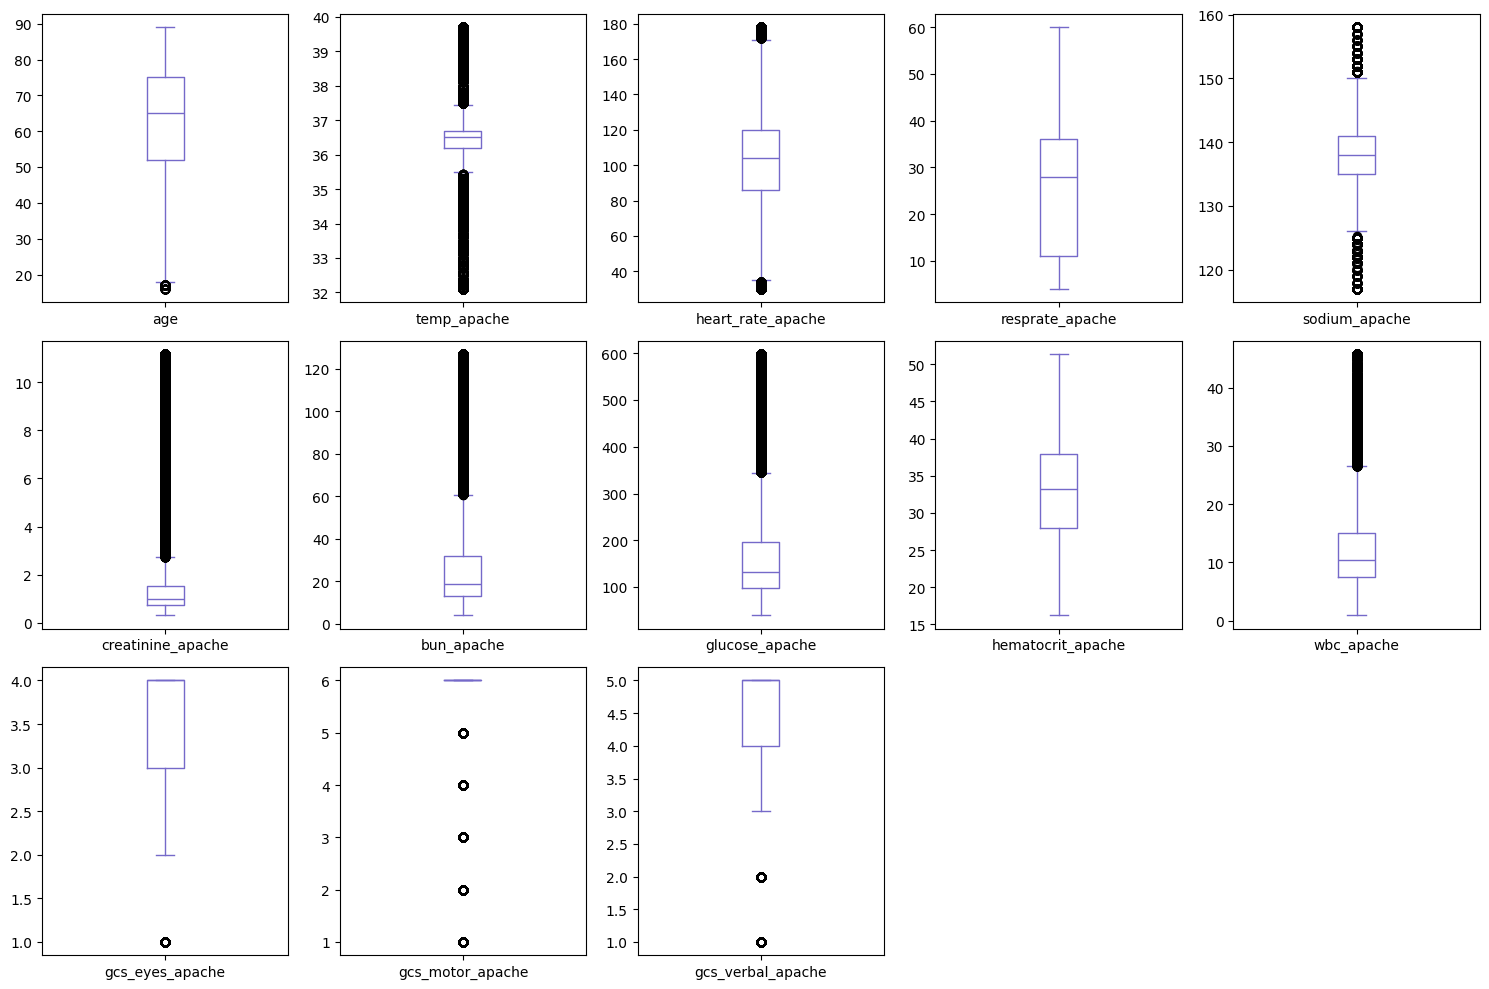

In [ ]:
description = df_apache.drop(['hospital_death', 'ventilated_apache', 'gcs_unable_apache', 'cirrhosis',
                              'hepatic_failure', 'lymphoma', 'leukemia', 'immunosuppression', 'aids',
                              'apache_post_operative', 'solid_tumor_with_metastasis'], axis=1)
description.plot(kind='box', subplots=True, layout=(3, 5), figsize=(15, 10), color='#7569c9')
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Outlier Detection using Interquartile Range (IQR) Method ---\n")

numerical_cols = df_apache.select_dtypes(include=['number']).columns.tolist()

# Identify binary columns to exclude
binary_cols = []
for col in numerical_cols:
    unique_values = df_apache[col].dropna().unique()
    if len(unique_values) <= 2 and all(val in [0, 1] for val in unique_values):
        binary_cols.append(col)

# Also exclude 'icu_admit_source_recoded' as it's a recoded categorical variable
exclusion_list = binary_cols + ['icu_admit_source_recoded', 'gcs_motor_apache']

# Filter out binary and explicitly excluded columns from the numerical columns list
filtered_numerical_cols = [col for col in numerical_cols if col not in exclusion_list]

for col in filtered_numerical_cols:
    Q1 = df_apache[col].quantile(0.25)
    Q3 = df_apache[col].quantile(0.75)
    IQR = Q3 - Q1

    # Using 3 * IQR as requested for more extreme outliers
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    outliers = df_apache[(df_apache[col] < lower_bound) | (df_apache[col] > upper_bound)][col]

    if not outliers.empty:
        print(f"Column: {col}")
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"  Number of outliers: {len(outliers)}")
        print(f"  Percentage of outliers: {(len(outliers) / len(df_apache[col].dropna()) * 100):.2f}% (relative to non-null values)")
        print(f"  Min Outlier Value: {outliers.min():.2f}, Max Outlier Value: {outliers.max():.2f}\n")

print("\n--- Outlier detection complete ---")


--- Outlier Detection using Interquartile Range (IQR) Method ---

Column: temp_apache
  Q1: 36.20, Q3: 36.70, IQR: 0.50
  Lower Bound: 34.70, Upper Bound: 38.20
  Number of outliers: 4601
  Percentage of outliers: 5.25% (relative to non-null values)
  Min Outlier Value: 32.10, Max Outlier Value: 39.70

Column: creatinine_apache
  Q1: 0.72, Q3: 1.53, IQR: 0.81
  Lower Bound: -1.71, Upper Bound: 3.96
  Number of outliers: 4314
  Percentage of outliers: 5.92% (relative to non-null values)
  Min Outlier Value: 3.97, Max Outlier Value: 11.18

Column: bun_apache
  Q1: 13.00, Q3: 32.00, IQR: 19.00
  Lower Bound: -44.00, Upper Bound: 89.00
  Number of outliers: 1583
  Percentage of outliers: 2.18% (relative to non-null values)
  Min Outlier Value: 89.10, Max Outlier Value: 127.00

Column: glucose_apache
  Q1: 97.00, Q3: 196.00, IQR: 99.00
  Lower Bound: -200.00, Upper Bound: 493.00
  Number of outliers: 889
  Percentage of outliers: 1.10% (relative to non-null values)
  Min Outlier Value: 494

In [ ]:
#Drop outliers
df_apache_nooutliers = df_apache.copy()

numerical_cols = df_apache_nooutliers.select_dtypes(include=['number']).columns.tolist()

# Identify binary columns to exclude (re-using the logic from outlier detection)
binary_cols = []
for col in numerical_cols:
    unique_values = df_apache_nooutliers[col].dropna().unique()
    if len(unique_values) <= 2 and all(val in [0, 1] for val in unique_values):
        binary_cols.append(col)

# Also exclude 'icu_admit_source_recoded' and 'gcs_motor_apache' from outlier removal
exclusion_list = binary_cols + ['icu_admit_source_recoded', 'gcs_motor_apache']

# Filter out binary and explicitly excluded columns from the numerical columns list
filtered_numerical_cols = [col for col in numerical_cols if col not in exclusion_list]

initial_rows = df_apache_nooutliers.shape[0]

for col in filtered_numerical_cols:
    Q1 = df_apache_nooutliers[col].quantile(0.25)
    Q3 = df_apache_nooutliers[col].quantile(0.75)
    IQR = Q3 - Q1

    # Using 3 * IQR for outlier detection (as in previous step)
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    # Filter out outliers for the current column
    df_apache_nooutliers = df_apache_nooutliers[
        (df_apache_nooutliers[col] >= lower_bound) |
        (df_apache_nooutliers[col].isna())]
    df_apache_nooutliers = df_apache_nooutliers[
        (df_apache_nooutliers[col] <= upper_bound) |
        (df_apache_nooutliers[col].isna())]

final_rows = df_apache_nooutliers.shape[0]

print(f"Shape of df_apache before outlier removal: ({initial_rows}, {df_apache.shape[1]}) ")
print(f"Shape of df_apache_nooutliers after outlier removal: ({final_rows}, {df_apache_nooutliers.shape[1]})")
print(f"Number of rows removed: {initial_rows - final_rows}")

Shape of df_apache before outlier removal: (91713, 29) 
Shape of df_apache_nooutliers after outlier removal: (80548, 29)
Number of rows removed: 11165


In [ ]:
df_apache_nooutliers.shape

(80548, 29)

In [ ]:
print(df_apache_nooutliers['age'].describe())

count    76694.000000
mean        62.363588
std         16.853515
min         16.000000
25%         52.000000
50%         65.000000
75%         75.000000
max         89.000000
Name: age, dtype: float64


In [ ]:
#Check class imbalance
hospital_death_percentages = df_apache_nooutliers['hospital_death'].value_counts(normalize=True) * 100
print("Percentage of patients for hospital_death (0=No Death, 1=Death):\n")
print(hospital_death_percentages)

Percentage of patients for hospital_death (0=No Death, 1=Death):

hospital_death
0    93.163083
1     6.836917
Name: proportion, dtype: float64


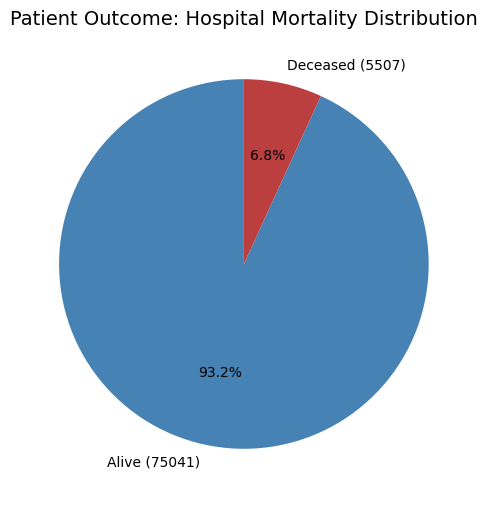

In [ ]:
# Count occurrences of each class
counts = df_apache_nooutliers['hospital_death'].value_counts()

# Define relevant colors: Green for Survived (0), Red for Deceased (1)
# Note: This assumes 0 is Survived and 1 is Deceased
colors = ['#4682B4', '#BB3F3F']

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    # Change labels to show 'Survived' or 'Deceased' instead of just 0 or 1
    labels=[f'{"Alive" if cls == 0 else "Deceased"} ({count})' for cls, count in counts.items()],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

# Set title
plt.title('Patient Outcome: Hospital Mortality Distribution', fontsize=14)

# Show plot
plt.show()

# Model Pipeline

**Pipeline order:**
1. Data splitting
2. Crossfold validation
3. Class imbalance (inside each fold)
4. Imputation
5. Normalization (some models)

## Data Splitting

In [ ]:
#Data splitting

X = df_apache_nooutliers.drop(['hospital_death'], axis=1)
y = df_apache_nooutliers['hospital_death']

#Split into 80% Train and 20% "Temporary" (which will become Val and Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Essential for medical data to keep mortality % consistent
)

#Split the 20% Temporary into 50% Validation and 50% Test (results in 10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Verify the sizes
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Remove temporary datasets
del X_temp, y_temp

Train: 64438 | Val: 8055 | Test: 8055


## K-Fold Cross Validation

Note: To combat Class Imbalance in the code

Random Forests: class_weight='balanced'

XGBoost: scale_pos_weight = total_negative_examples / total_positive_examples -> It forces the gradient boosting trees to pay much more attention to the minority (death) class

## Random Forest & XGBoost

In [ ]:
# Calculate XGBoost imbalance ratio once
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Define the Random Forest Pipeline
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Define the XGBoost Pipeline
xgb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, scale_pos_weight=ratio))
])

# Define Hyperparameters to test
param_grid_rf = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [10, 20, None],
}

param_grid_xgb = {
    "xgb__learning_rate": [0.01, 0.1],
    "xgb__max_depth": [3, 6],
    "xgb__n_estimators": [100, 200]
}

In [ ]:
# Tune Random Forest
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

# Tune XGBoost
grid_xgb = GridSearchCV(xgb_pipe, param_grid_xgb, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

# Compare on the Validation Set
rf_val_f1 = f1_score(y_val, grid_rf.predict(X_val))
xgb_val_f1 = f1_score(y_val, grid_xgb.predict(X_val))

print(f"--- VALIDATION RESULTS ---")
print(f"Random Forest F1: {rf_val_f1:.4f}")
print(f"XGBoost F1:       {xgb_val_f1:.4f}")

# Pick the winner
winner = grid_xgb if xgb_val_f1 > rf_val_f1 else grid_rf
winner_name = "XGBoost" if xgb_val_f1 > rf_val_f1 else "Random Forest"
print(f"\nTHE WINNER IS: {winner_name}")

--- VALIDATION RESULTS ---
Random Forest F1: 0.3352
XGBoost F1:       0.3414

THE WINNER IS: XGBoost


In [ ]:
# Get stats from the winner
y_pred = winner.predict(X_test)
y_proba = winner.predict_proba(X_test)[:, 1] # Probability of the '1' (Deceased) class

In [ ]:
# Classification Report
print(f"--- Final Report: {winner_name} ---")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Deceased']))

--- Final Report: XGBoost ---
              precision    recall  f1-score   support

    Survived       0.97      0.83      0.90      7505
    Deceased       0.23      0.69      0.34       550

    accuracy                           0.82      8055
   macro avg       0.60      0.76      0.62      8055
weighted avg       0.92      0.82      0.86      8055



In [ ]:
# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC Score: {auc_score:.4f}")

AUC-ROC Score: 0.8414


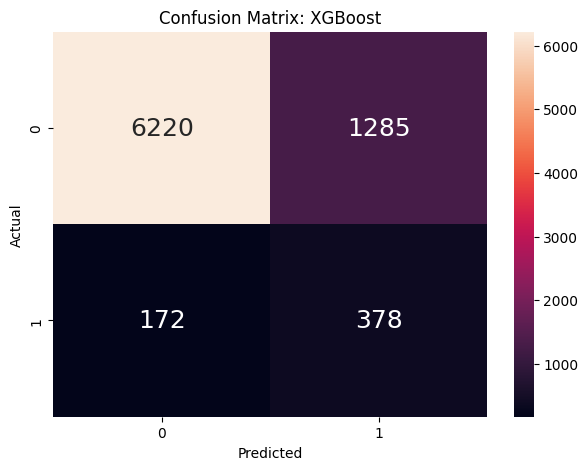

In [ ]:
# Calculate matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Define custom "Scary but Sane" colormap (Cadet Blue to Dark Red)
cmap = sns.diverging_palette(210, 10, as_cmap=True)

# Visualizing confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', annot_kws={"size": 18})

plt.title(f'Confusion Matrix: {winner_name}', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

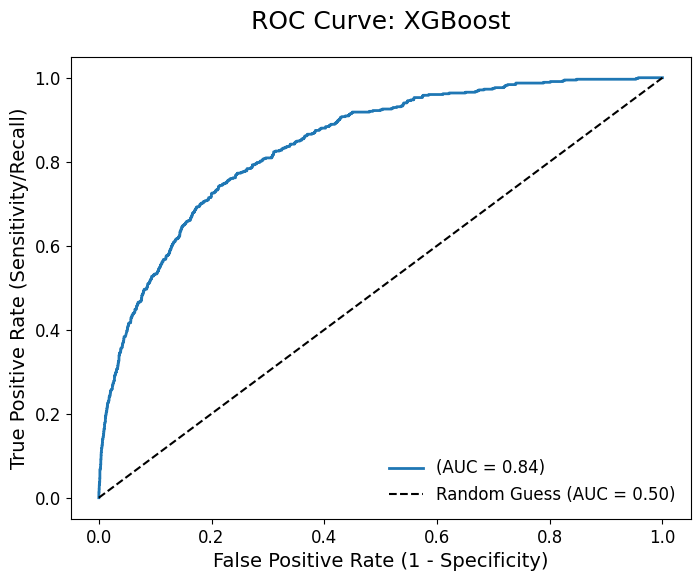

In [ ]:
# Get probabilities from the winner (XGBoost or RF)
y_probs = winner.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))

# Standard blue line with increased thickness
plt.plot(fpr, tpr, color='tab:blue', lw=2, label=f'(AUC = {auc_score:.2f})')

# 'k--' is the black dashed line for the random baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess (AUC = 0.50)')

# Formatting with increased font sizes
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14)
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=14)
plt.title(f'ROC Curve: {winner_name}', fontsize=18, pad=20)

# Legend and Ticks
plt.legend(fontsize=12, loc='lower right', frameon=False) # No box around legend for "No Grid" look
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Ensure no grid is shown
plt.grid(False)

plt.show()